In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# -------------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
import random

In [ ]:
import tensorflow as tf

#STEP 3: Load Dataset
data_dir = "/content/drive/MyDrive/soil_dataset"

data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)
class_names = data.class_names
print("Classes:", class_names)

Found 1737 files belonging to 4 classes.
Classes: ['Alluvial_Soil', 'Black_Soil', 'Red_Soil', 'Yellow_Soil']


In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

data = data.map(lambda x, y: (preprocess_input(x), y))

In [ ]:
#STEP 5: Train-Test Split
train_size = int(0.8 * len(data))
train = data.take(train_size)
test = data.skip(train_size)

In [ ]:


#STEP 6: Data Augmentation (IMPROVES GENERALIZATION)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

In [ ]:
# STEP 7: Load VGG16
base_model = tf.keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# partial training (IMPORTANT)
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
#STEP 8: Build Model
model = keras.Sequential([
    data_augmentation,
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
#STEP 9: Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#STEP 10: Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

In [ ]:


# STEP 11: Train Model
history = model.fit(
    train,
    validation_data=test,
    epochs=15,
    #callbacks=[early_stop]
)

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 368s 8s/step - accuracy: 0.7145 - loss: 1.1850 - val_accuracy: 0.9301 - val_loss: 0.2442
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 355ms/step - accuracy: 0.9517 - loss: 0.1563 - val_accuracy: 0.9726 - val_loss: 0.0784
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 350ms/step - accuracy: 0.9822 - loss: 0.0706 - val_accuracy: 0.9726 - val_loss: 0.0749
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 356ms/step - accuracy: 0.9794 - loss: 0.0705 - val_accuracy: 0.9818 - val_loss: 0.0850
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 366ms/step - accuracy: 0.9865 - loss: 0.0560 - val_accuracy: 0.9909 - val_loss: 0.0649
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 359ms/step - accuracy: 0.9858 - loss: 0.0386 - val_accuracy: 0.9878 - val_loss: 0.0825
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 356ms/step - accuracy: 0.9730 - loss: 0.0999 - val_accuracy: 0.9818 - val_loss: 0.0600
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 357ms/step - accuracy: 0.9837 - loss: 0.0452 - val_accura

In [ ]:
# STEP 12: Evaluate
model.evaluate(test)
# STEP 13: Upload Image for Prediction
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - accuracy: 0.9939 - loss: 0.0477


Saving y (1175).jpeg to y (1175).jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step


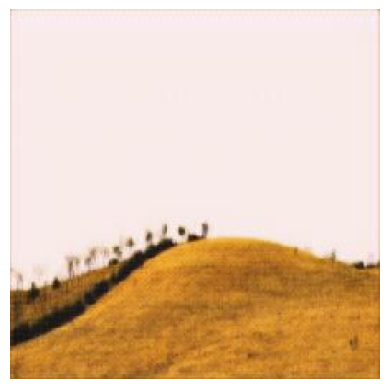

In [ ]:
# STEP 14: Predict
img = keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.axis('off')

img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# SAME preprocessing as training
img_array = preprocess_input(img_array)

prediction = model.predict(img_array)
score = prediction[0]


Prediction Probabilities:
Alluvial_Soil: 0.00%
Black_Soil: 0.00%
Red_Soil: 0.00%
Yellow_Soil: 100.00%

Final Prediction: Yellow_Soil
Confidence: 100.00%
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.9939 - loss: 0.0480

 Model Accuracy: 99.39%

Prediction Probabilities:
Alluvial_Soil: 0.00%
Black_Soil: 0.00%
Red_Soil: 0.00%
Yellow_Soil: 100.00%


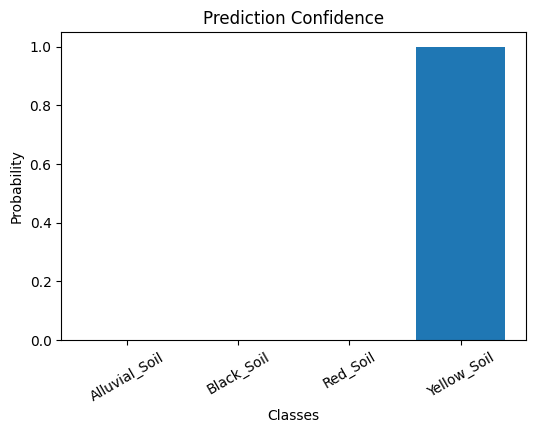


Final Prediction: Yellow_Soil
Confidence: 100.00%

Suitable Crops:
• Maize
• Groundnut
• Pulses
• Millets
• Potato
• Rice
• Tea
• Fruits


In [ ]:
# STEP 15: Output
print("\nPrediction Probabilities:")
for i in range(len(class_names)):
    print(f"{class_names[i]}: {score[i]*100:.2f}%")

predicted_class = class_names[np.argmax(score)].replace("Potato___", "")
confidence = np.max(score) * 100

print(f"\nFinal Prediction: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")
loss, accuracy = model.evaluate(test)
print(f"\n Model Accuracy: {accuracy*100:.2f}%")



print("\nPrediction Probabilities:")
for i in range(len(class_names)):
    print(f"{class_names[i]}: {score[i]*100:.2f}%")


# BAR GRAPH FOR PROBABILITIES
plt.figure(figsize=(6,4))
plt.bar(class_names, score)
plt.xlabel("Classes")
plt.ylabel("Probability")
plt.title("Prediction Confidence")
plt.xticks(rotation=30)
plt.show()

# Final Prediction
predicted_class = class_names[np.argmax(score)].replace("Potato___", "")
confidence = np.max(score) * 100

print(f"\nFinal Prediction: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

soil_crop_map = {
    "Alluvial_Soil": [
        "Rice", "Wheat", "Sugarcane", "Maize",
        "Pulses", "Jute", "Mustard", "Vegetables"
    ],
    "Black_Soil": [
        "Cotton", "Soybean", "Groundnut", "Wheat",
        "Sugarcane", "Sunflower", "Millets", "Pulses"
    ],
    "Red_Soil": [
        "Groundnut", "Millets", "Pulses", "Potato",
        "Cotton", "Tobacco", "Oilseeds", "Fruits"
    ],
    "Yellow_Soil": [
        "Maize", "Groundnut", "Pulses", "Millets",
        "Potato", "Rice", "Tea", "Fruits"
    ]
}

print("\nSuitable Crops:")
if predicted_class in soil_crop_map:
    for crop in soil_crop_map[predicted_class]:
        print(f"• {crop}")
else:
    print("No crop recommendations available.")